In [2]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground 
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

## Cosmology: Background and Perturbations

This code snippet initializes and computes the cosmological background and perturbations at various redshifts using the **CAMB** and **HMCode2020Emu** interfaces.

In [3]:
zs = np.linspace(1e-4, 3, 100)

# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545,
                            N_mnu = 1)
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, zs, log10TAGN=7.8)

## Download and Read the Data

In this step, we use the `euclidlib` library to read the data, which follows . `euclidlib` provides the necessary functions and utilities to access and handle data from the Euclid mission, allowing us to seamlessly retrieve, process, and analyze the large datasets generated by the mission. 

For this tutorial, we use example synthetic data stored at https://zenodo.org/communities/cloe-org


In [4]:
# Execute this cell to download the data
data_downloaded = True

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'mixmats_example.fits': 'https://zenodo.org/records/17191365/files/example-mixmats.fits',
        'cls_example.fits': 'https://zenodo.org/records/17191365/files/example-spectra.fits'
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

In [5]:
# Read the data using euclidlib v2025.w
# Remember, only pip install euclidlib necessary!

z_nz, nz_example = el.phz.redshift_distributions('nz_example.fits')
cls_example = el.le3.pk_wl.angular_power_spectra('cls_example.fits')
mixmats_example = el.le3.pk_wl.mixing_matrices('mixmats_example.fits')

## Plot the galaxy redshift distribution $n(z)$

We use a synthetic galaxy redshift bin distribution that contains 6 redshift bins. We assume that both sources and lenses follow the same distributions.

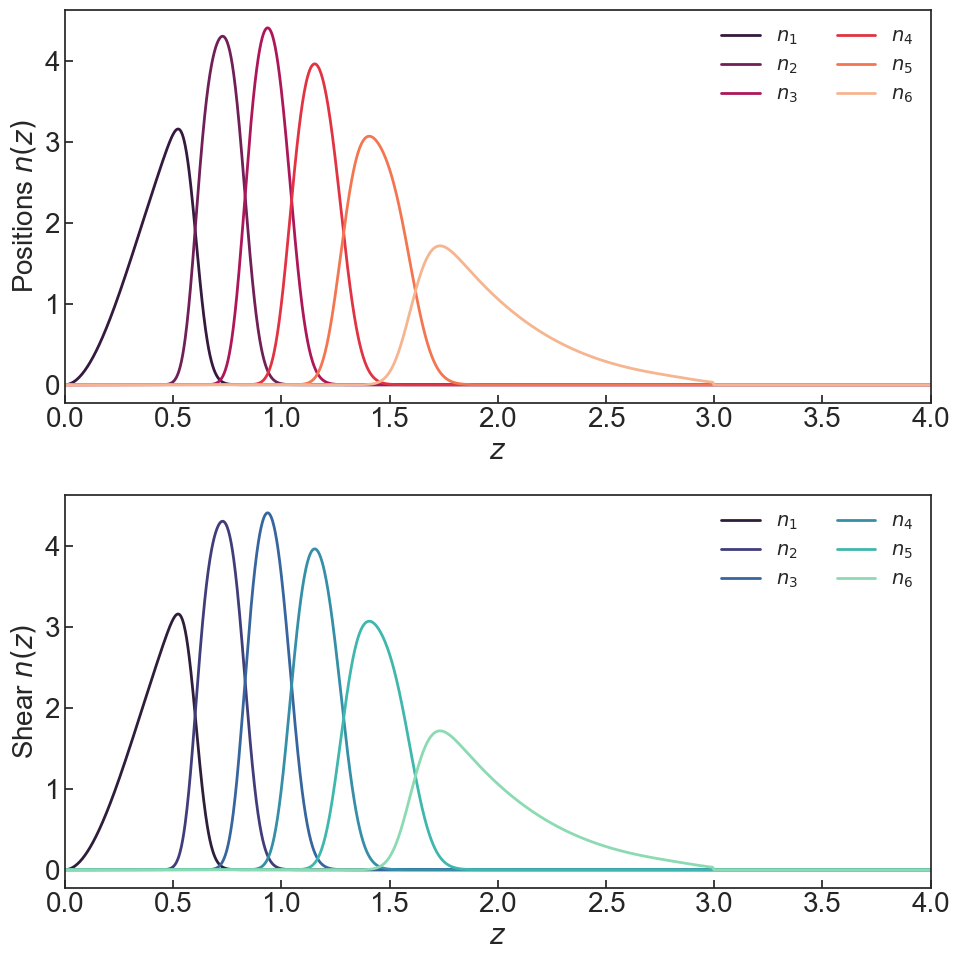

In [6]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

## Observables: shear and position tracers 

We compute tracers (window functions) for both shear and galaxy positions observations, to be later combined in the computation of the summary statistics.

In [7]:
# Select the perturbations object you want to use
perturbations = nonlinear_perturbations_emu

# Define the tracers
tracer_pos = PositionsTracer(perturbations=perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             galaxy_bias_model='poly',
                             nuisance_params={'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0, 
                                              'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
                                              'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                                              'dz_pos_1': 0.0, 'dz_pos_2': 0.0,
                                              'dz_pos_3': 0.0, 'dz_pos_4': 0.0,
                                              'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
                                              'width_pos_1': 1.0, 'width_pos_2': 1.0,
                                              'width_pos_3': 1.0, 'width_pos_4': 1.0,
                                              'width_pos_5': 1.0, 'width_pos_6': 1.0})

tracer_she = ShearTracer(perturbations=perturbations, 
                             dndz=my_dndz_she_norm,
                             z = zs,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41,
                                              'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                                              'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                                              'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                                              'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                                              'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                                              'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
                                              'width_shear_1': 1.0, 'width_shear_2': 1.0,
                                              'width_shear_3': 1.0, 'width_shear_4': 1.0,
                                              'width_shear_5': 1.0, 'width_shear_6': 1.0},
                             ia_model='NLA')

In [8]:
from cloelib.observables.photo.shear import PBJTATTLoopComputer

# Build a second ShearTracer identical to `tracer_she` above, except using
# the TATT intrinsic-alignment model instead of the default NLA. A1/C_IA/eta1
# match the NLA nuisance params used to build `tracer_she` above; A2/b_TA/eta2/z0
# are the zTATT fiducial values from Table 3 of the reference paper.
# FAST-PT's one-loop integrals need the *linear* Pk, but PBJTATTLoopComputer
# takes the same `perturbations` you already have (the nonlinear emulator,
# used for the tree-level C1**2*P_dd term) - it resolves the linear source
# itself via `perturbations.linearperturbations`.
nuisance_shear_tatt = {'AIA': 1.72, 'CIA': 0.0134, 'EtaIA': -0.41,
                        'A2IA': 0.40, 'bTA': -0.83, 'Eta2IA': 2.69, 'z0IA': 0.62,
                        'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                        'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                        'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                        'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                        'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                        'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
                        'width_shear_1': 1.0, 'width_shear_2': 1.0,
                        'width_shear_3': 1.0, 'width_shear_4': 1.0,
                        'width_shear_5': 1.0, 'width_shear_6': 1.0}

tracer_she_tatt = ShearTracer(perturbations=perturbations,
                               dndz=my_dndz_she_norm,
                               z=zs,
                               nuisance_params=nuisance_shear_tatt,
                               ia_model="TATT",
                               tatt_loop_computer=PBJTATTLoopComputer(perturbations))

print(f"NLA:  tracer_she.ia      -> {type(tracer_she.ia).__name__}")
print(f"TATT: tracer_she_tatt.ia -> {type(tracer_she_tatt.ia).__name__}  "
      f"(loop_computer={type(tracer_she_tatt.ia._loop_computer).__name__})")

NLA:  tracer_she.ia      -> NLAContribution
TATT: tracer_she_tatt.ia -> TATTContribution  (loop_computer=PBJTATTLoopComputer)


In [9]:
# The engine only computes the one-loop terms a given contribution *pairing*
# actually needs: II (shear-shear self-correlation) needs all ten kernel
# terms (Eqs. 13-14), but GI (position-shear cross-correlation) only needs
# the four that appear in Eq. 15 - mirroring the same "avoid computing
# unneeded PT terms" optimization the toy_cloelib sandbox demonstrated first.
ii_reqs = [r.name for r in tracer_she_tatt.ia.get_requirements_for_interaction(tracer_she_tatt.ia)]
gi_reqs = [r.name for r in tracer_she_tatt.ia.get_requirements_for_interaction(tracer_she_tatt.lensing)]

print(f"One-loop terms requested for II (shear-shear, self-pair): {len(ii_reqs)}  {ii_reqs}")
print(f"One-loop terms requested for GI (position-shear pair):    {len(gi_reqs)}  {gi_reqs}")

One-loop terms requested for II (shear-shear, self-pair): 10  ['tatt_A_0_0E', 'tatt_C_0_0E', 'tatt_A_0E_0E', 'tatt_A_E2_E2', 'tatt_A_0_E2', 'tatt_B_0_E2', 'tatt_D_0E_E2', 'tatt_A_0B_0B', 'tatt_A_B2_B2', 'tatt_D_0B_B2']
One-loop terms requested for GI (position-shear pair):    4  ['tatt_A_0_0E', 'tatt_C_0_0E', 'tatt_A_0_E2', 'tatt_B_0_E2']


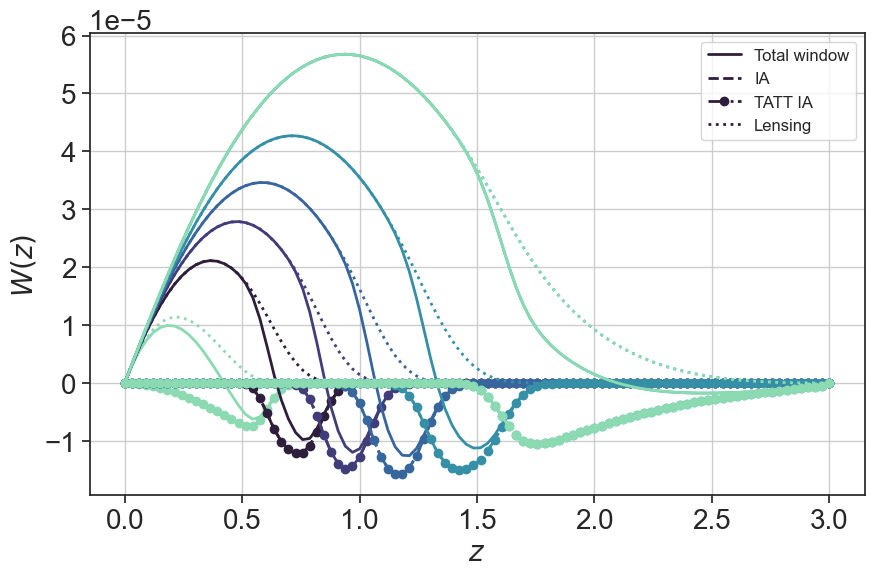

In [12]:
colors = sns.color_palette("mako", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop

for i in range(0, 7):
    # Plot the window
    plt.plot(perturbations.z, 
             tracer_she.get_window(perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window for the NLA model
    plt.plot(perturbations.z, 
             tracer_she.get_window_IA(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'IA' if i == 1 else "")

    # Plot the intrinsic alignment window for the TATT model
    plt.plot(perturbations.z,
             tracer_she_tatt.get_window_IA(perturbations.z)[i, :],
             linewidth=2,
             linestyle='-.',
             marker='o',
             color=colors[i-1],
             label=f'TATT IA' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(perturbations.z, 
             tracer_she.get_window_lensing(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Lensing' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$')
plt.ylabel(r'$W(z)$')

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()


## Two-point statistics

### Theoretical Predictions: $C_\ell$

We compute angular power spectra initialising the corresponding `cloelib` class. First, we plot the $C_\ell$ without the convolution with the mixing matrices.

In [14]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_posshe = AngularTwoPoint(tracer_pos, tracer_she)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

cells ={**twopoint_pospos.get_Cl(ells, 0, perturbations.k)
, **twopoint_posshe.get_Cl(ells, 0, perturbations.k)
, **twopoint_sheshe.get_Cl(ells, 0, perturbations.k)}

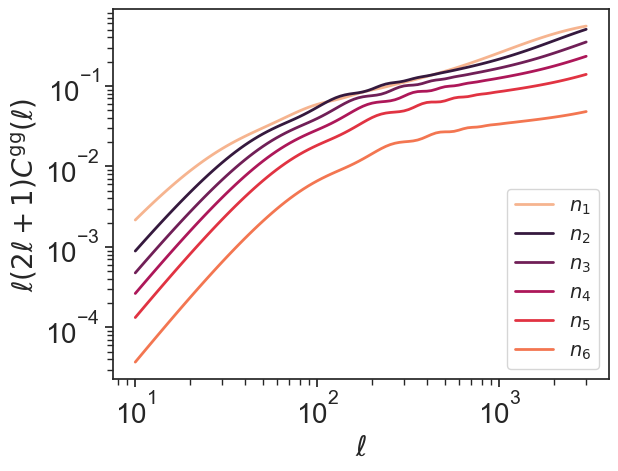

In [15]:
for i in range(0, 6):
    ells = cells['POS', 'POS', i+1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells['POS', 'POS', i+1, i+1], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$');
plt.legend(fontsize=14);

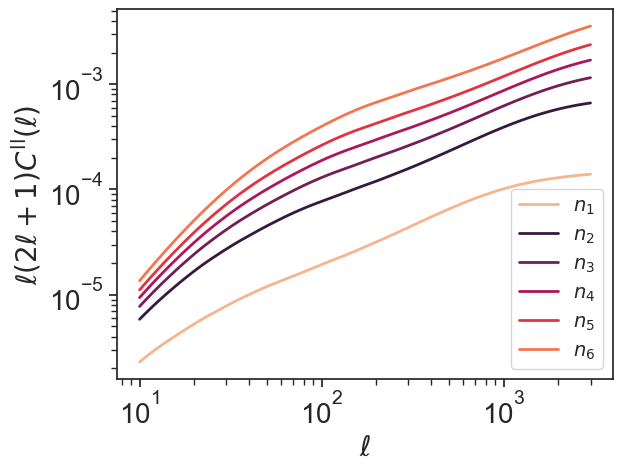

In [16]:
for i in range(0, 6):
    ells = cells['SHE', 'SHE', i+1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells['SHE', 'SHE', i+1, i+1][0, 0], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm ll}(\ell)$');
plt.legend(fontsize=14);

#### NLA vs TATT: comparing intrinsic-alignment models

`AngularTwoPoint.get_Cl` doesn't know or care which intrinsic-alignment model a `ShearTracer` uses - it works identically for `tracer_she_tatt` (TATT, built above) as it does for `tracer_she` (NLA). We compute both and compare their shear-shear $C_\ell^{EE}$.

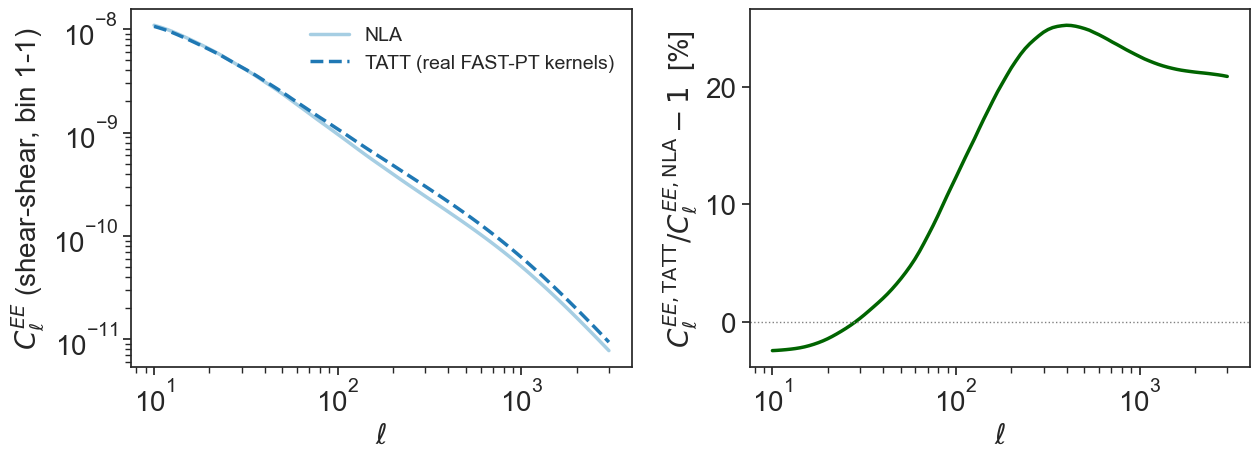

max |deviation| from NLA (real FAST-PT): 25.26%


In [19]:
# Compute Cl exactly as for the NLA tracers above - AngularTwoPoint.get_Cl
# doesn't know or care that this tracer uses a different IA model.
# Use the ell grid actually stored on the NLA result (`ells` itself gets
# reassigned by the per-bin plotting loops above), so this stays correct
# regardless of what ran just before it.
ells_plot = cells[("SHE", "SHE", 1, 1)].ell

twopoint_sheshe_tatt = AngularTwoPoint(tracer_she_tatt, tracer_she_tatt)
cells_tatt = {**twopoint_sheshe_tatt.get_Cl(ells_plot, 0, perturbations.k)}

ee_nla = np.asarray(cells[("SHE", "SHE", 1, 1)].array[0, 0])
ee_tatt = np.asarray(cells_tatt[("SHE", "SHE", 1, 1)].array[0, 0])

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].loglog(ells_plot, ee_nla, label="NLA", lw=2.5)
axs[0].loglog(ells_plot, ee_tatt, label="TATT (real FAST-PT kernels)", lw=2.5, linestyle="--")
axs[0].set_xlabel(r"$\ell$")
axs[0].set_ylabel(r"$C_\ell^{EE}$ (shear-shear, bin 1-1)")
axs[0].legend(frameon=False)

axs[1].semilogx(ells_plot, (ee_tatt / ee_nla - 1) * 100, color="darkgreen", lw=2.5)
axs[1].axhline(0, color="0.5", lw=1, ls=":")
axs[1].set_xlabel(r"$\ell$")
axs[1].set_ylabel(r"$C_\ell^{EE,\rm TATT}/C_\ell^{EE,\rm NLA} - 1$  [%]")

plt.tight_layout()
plt.show()

print("max |deviation| from NLA (real FAST-PT): %.2f%%" % np.max(np.abs(ee_tatt / ee_nla - 1) * 100))

The TATT curve tracks NLA closely at low $\ell$ and grows to tens of percent through the one-loop-relevant scales - the qualitative shape expected of a real TATT one-loop correction, since these are real FAST-PT-computed kernels, not a tuned stand-in.

Setting `A2IA=0`, `bTA=0`, `z0IA=0` reproduces the NLA curve exactly (every one-loop kernel term is multiplied by a zero amplitude in that limit) - see `cloelib`'s `test_tatt.py::test_tatt_matches_legacy_nla_end_to_end_at_z0_zero` and `::test_pbj_tatt_reduces_to_nla_form_when_a2_and_bta_zero`.

In [22]:
import time

# Use a fresh ell grid and fresh AngularTwoPoint objects
ells_timing = np.logspace(1, np.log10(3000), nl)

start_nla = time.perf_counter()
cells_nla_timing = AngularTwoPoint(
    tracer_she, tracer_she
).get_Cl(ells_timing, 0, perturbations.k)
time_nla = time.perf_counter() - start_nla

start_tatt = time.perf_counter()
cells_tatt_timing = AngularTwoPoint(
    tracer_she_tatt, tracer_she_tatt
).get_Cl(ells_timing, 0, perturbations.k)
time_tatt = time.perf_counter() - start_tatt

print(f"NLA C_ell calculation:  {time_nla:.3f} s")
print(f"TATT C_ell calculation: {time_tatt:.3f} s")
print(f"TATT/NLA time ratio:     {time_tatt / time_nla:.2f}x")

NLA C_ell calculation:  0.029 s
TATT C_ell calculation: 0.032 s
TATT/NLA time ratio:     1.11x


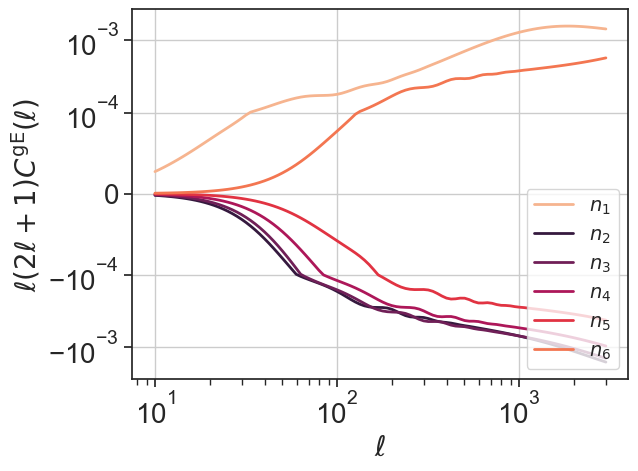

In [23]:
for i in range(0, 6):
    ells = cells['POS', 'SHE', i+1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells['POS', 'SHE', i+1, i+1][0], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])

# Labels and legend
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gE}(\ell)$')
plt.legend(fontsize=14, loc=4)

# Set y-axis to symmetric log scale to handle negative values
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('log')
# Show the grid and the plot
plt.grid(True)
plt.show()

In [24]:
ell_like = np.array([  10,   12,   15,   18,   21,   26,   31,   37,   44,   53,   64,
         77,   92,  110,  132,  158,  189,  226,  270,  323,  387,  462,
        553,  661,  790,  944, 1129, 1349, 1613, 1928, 2304, 2754])
cells_for_like ={**twopoint_pospos.get_Cl(ell_like, 0, perturbations.k)
, **twopoint_posshe.get_Cl(ell_like, 0, perturbations.k)
, **twopoint_sheshe.get_Cl(ell_like, 0, perturbations.k)}

### Theoretical Predictions: pseudo-$C_\ell$

Now, we plot the $C_\ell$ without the convolution with the mixing matrices.

In [25]:
cells_PP = twopoint_pospos.get_pseudo_Cl(0, perturbations.k,mixmats_example)
cells_SS = twopoint_sheshe.get_pseudo_Cl(nl, perturbations.k,mixmats_example)
cells_PS = twopoint_posshe.get_pseudo_Cl(nl, perturbations.k,mixmats_example)

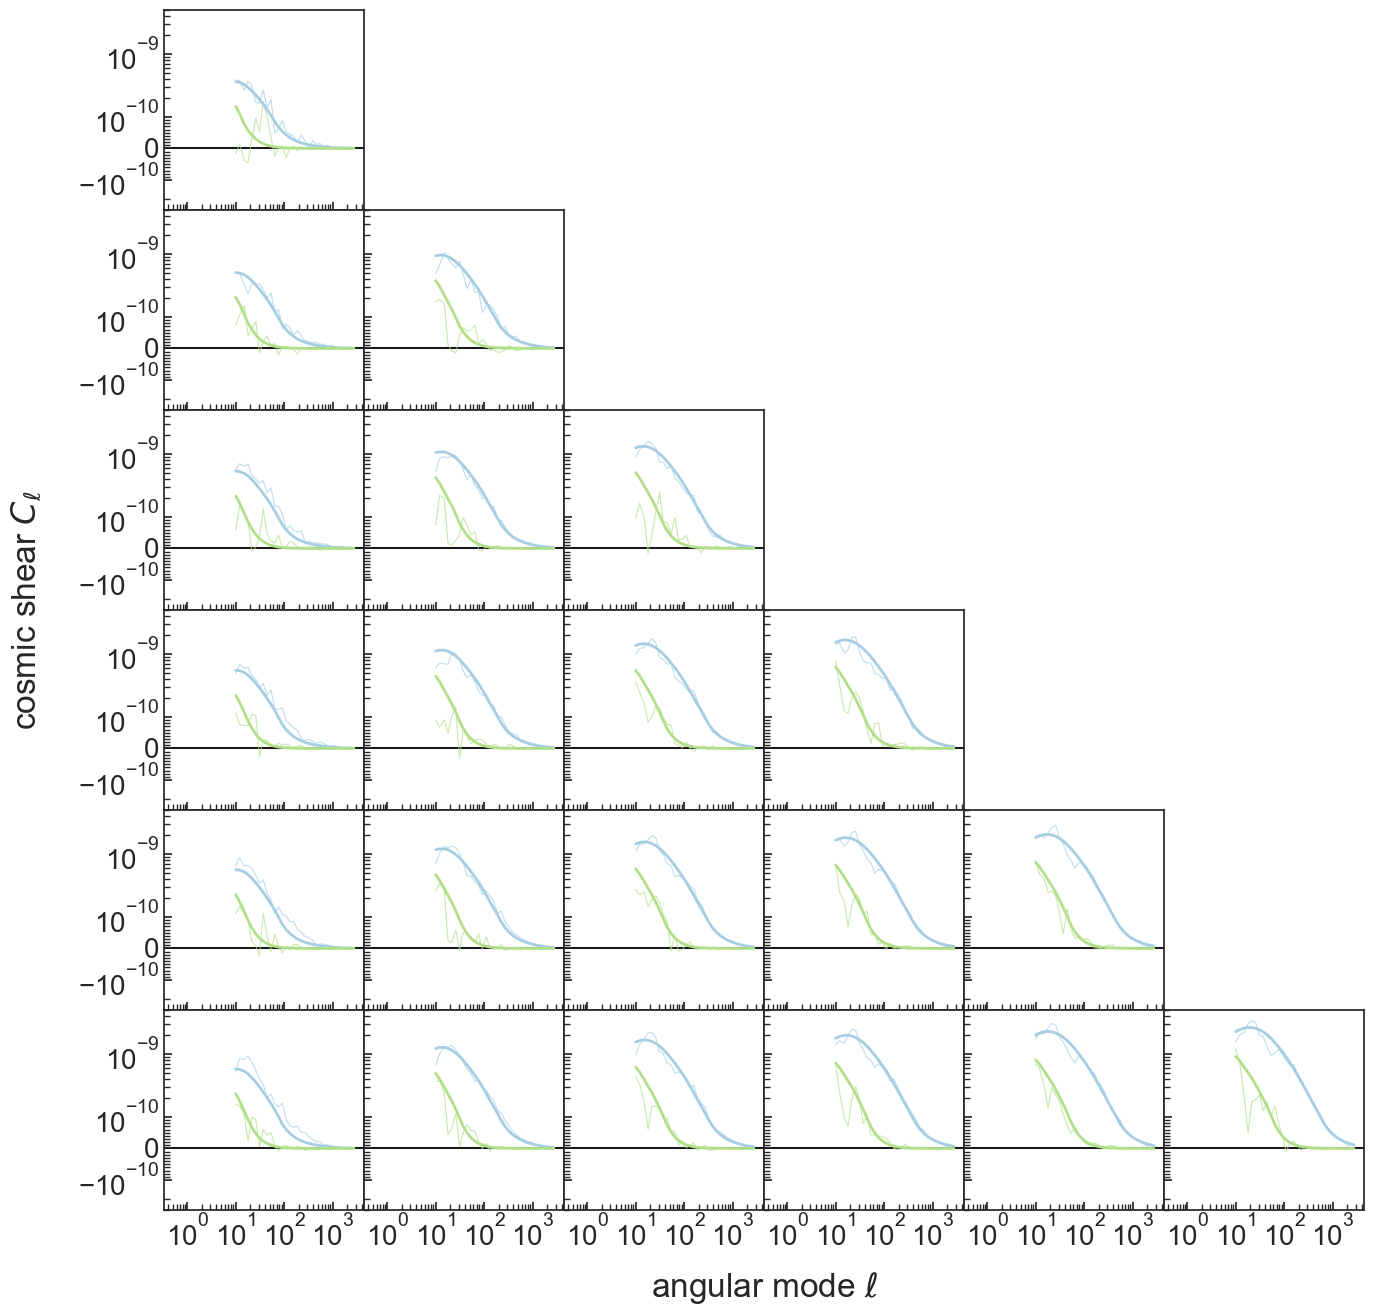

In [26]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            cls_example["SHE", "SHE",i, j].ell,
            cls_example["SHE", "SHE",i, j][0, 0],
            c="C0",
            lw=0.8,
            zorder=3.0,
            alpha=0.7,
        )
        ax[j - 1, i - 1].plot(
            cells_SS["SHE", "SHE",i, j].ell, cells_SS["SHE", "SHE",i, j][0, 0], c="C0", lw=2.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            cls_example["SHE", "SHE",i, j].ell,
            cls_example["SHE", "SHE",i, j][1, 1],
            c="C2",
            lw=0.8,
            zorder=1.0,
            alpha=0.7,
        )
        ax[j - 1, i - 1].plot(
            cells_SS["SHE", "SHE",i, j].ell, cells_SS["SHE", "SHE",i, j][1, 1], c="C2", lw=2.0, zorder=4.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=1.5, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(1 / 3, 1500 * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-3e-10, 5e-9)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$", x=-0.1, ha="right")

plt.show()

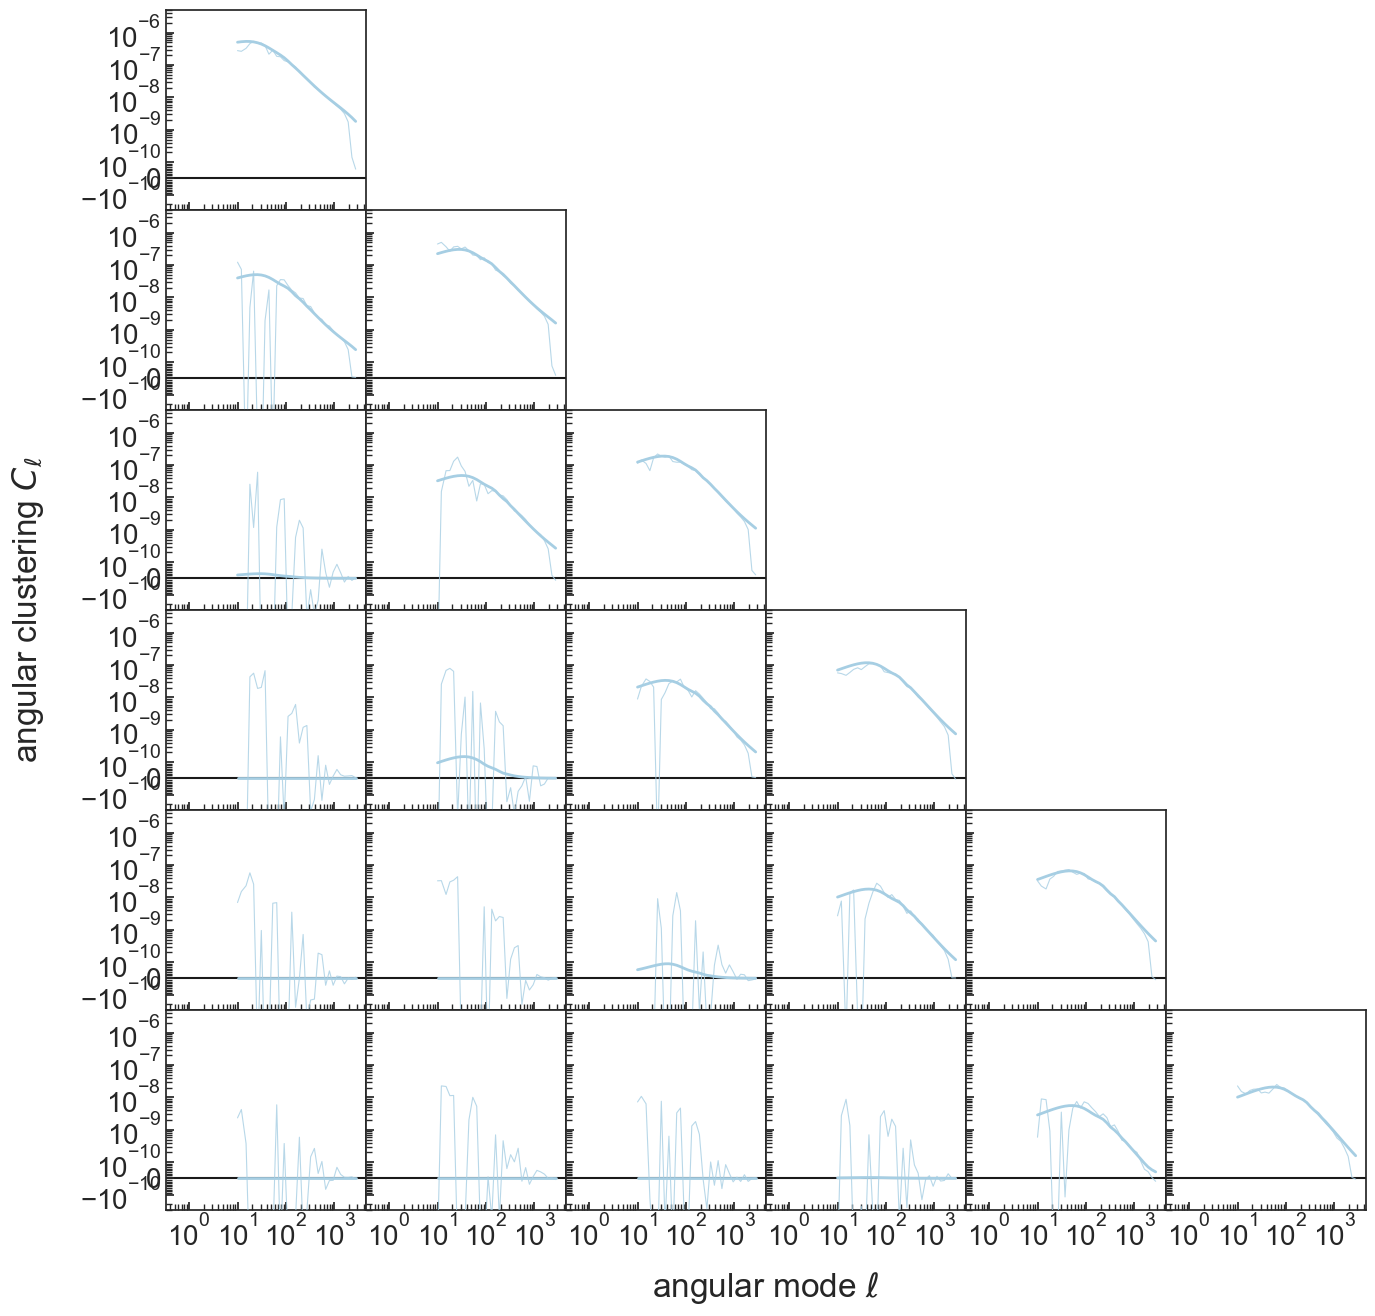

In [27]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            cls_example["POS", "POS",i, j].ell,
            cls_example["POS", "POS",i, j],
            c="C0",
            lw=0.8,
            zorder=3.0,
            alpha=0.8,
        )
        ax[j - 1, i - 1].plot(
            cells_PP["POS", "POS",i, j].ell, cells_PP["POS", "POS",i, j], c="C0", lw=2.0, zorder=4.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=1.5, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(1 / 3, 1500 * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-3e-10, 5e-6)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("angular clustering $C_\\ell$", x=-0.1, ha="right")

plt.show()

### Angular two-point correlation functions

We compute the angular correlation functions ($\xi$) from the $C(\ell)$. The calculation automatically calculates the correlation function for all tomo bin combinations at with $C(\ell)$ is defined.

In [19]:
# Define at which theta to evaluate the correlation function

theta_deg = np.geomspace(5, 100, 20)/60 # in degrees
theta_rad = np.deg2rad(theta_deg)  # in radians

We first calculate the position-position correlation function and plot the auto-correlations

In [20]:
# Position-Position correlation function

ells_integration = np.arange(2, 60000)  # Multipole moments over which to integrate
# Initialize correlation function calculation object
correlation_function_GG = AngularCorrelationFunctionWigner(twopoint_pospos, ells_integration, perturbations.k)

In [21]:
# Get correlation function at the defined thetas (NOTE: this takes the separation in radians!)
# First time this will be a bit slow, but it will be faster the next time you run it since the results are cached
xi_pospos = correlation_function_GG.get_xi(theta_rad)

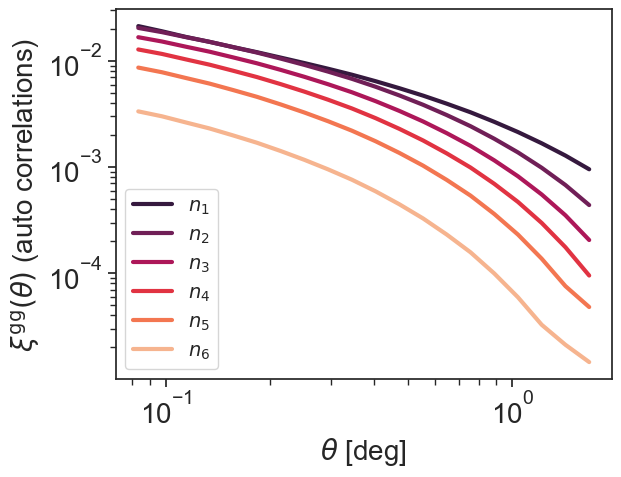

In [22]:
# plot

fig, ax = plt.subplots()

for i, color in zip(range(0, 6), sns.color_palette("rocket", len(dndz_pos_norm))):
    ax.loglog(np.rad2deg(xi_pospos["POS","POS",i+1,i+1].theta), xi_pospos["POS","POS",i+1,i+1], c=color,
              label=f"$n_{i+1}$")
    
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\xi^{\rm gg}(\theta)$ (auto correlations)')

ax.legend()

In [23]:
ells_integration = np.arange(2, 60000)  # Multipole moments over which to integrate

# Initialize correlation function calculation object
correlation_function_EG = AngularCorrelationFunctionWigner(twopoint_shepos, ells_integration, perturbations.k)

In [24]:
# Get correlation function at the defined thetas (NOTE: this takes the separation in radians!)
xi_shepos = correlation_function_EG.get_xi(theta_rad)

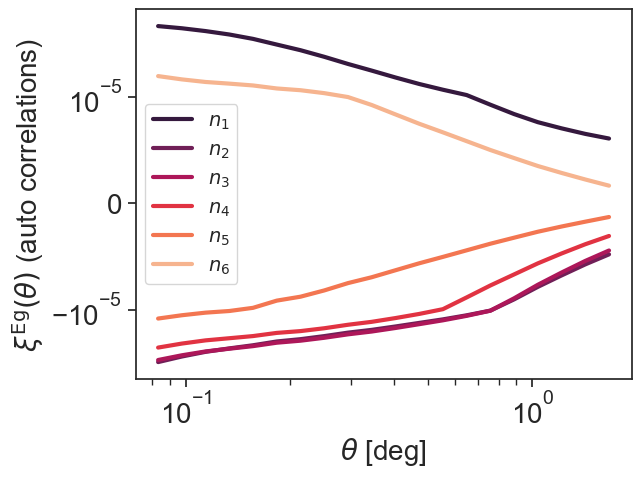

In [25]:
# plot
fig, ax = plt.subplots()

for i, color in zip(range(0, 6), sns.color_palette("rocket", len(dndz_pos_norm))):
    ax.loglog(np.rad2deg(xi_shepos["SHE","POS", i+1, i+1].theta), xi_shepos["SHE","POS", i+1, i+1][0], c=color,
              label=f"$n_{i+1}$")
    
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\xi^{\rm Eg}(\theta)$ (auto correlations)')
# Set y-axis to symmetric log scale to handle negative values
ax.set_yscale('symlog', linthresh=1e-5)
ax.legend()

In [26]:
ells_integration = np.arange(2, 30000)  # Multipole moments over which to integrate
# Initialize correlation function calculation object
correlation_function_EE = AngularCorrelationFunctionWigner(twopoint_sheshe, ells_integration, perturbations.k)

In [27]:
# Get correlation function at the defined thetas (NOTE: this takes the separation in radians!)
xi_sheshe = correlation_function_EE.get_xi(theta_rad)

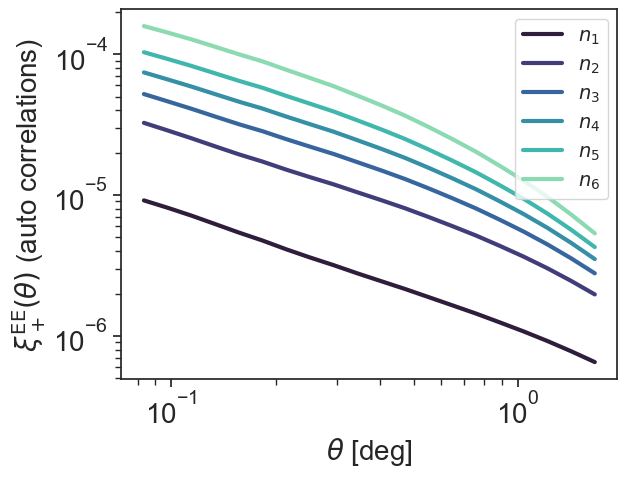

In [28]:
# plot
fig, ax = plt.subplots()

for i, color in zip(range(0, 6), sns.color_palette("mako", len(dndz_she_norm))):
    ax.loglog(np.rad2deg(xi_sheshe["SHE","SHE", i+1, i+1].theta), xi_sheshe["SHE","SHE", i+1, i+1][0,0], c=color,
              label=f"$n_{i+1}$")
    
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\xi^{\rm EE}_+(\theta)$ (auto correlations)')

ax.legend()

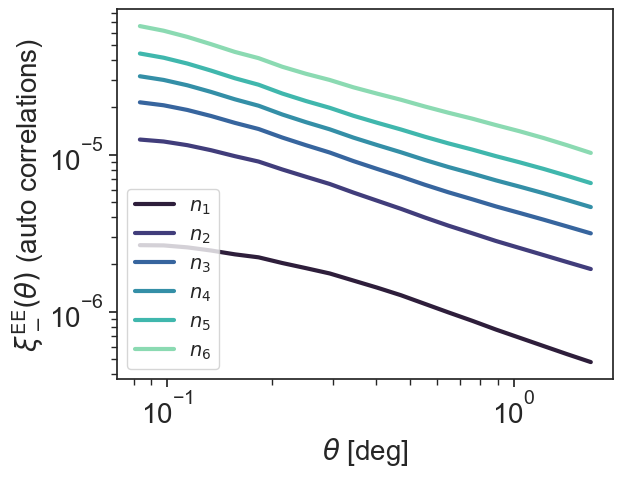

In [29]:
# plot
fig, ax = plt.subplots()

for i, color in zip(range(0, 6), sns.color_palette("mako", len(dndz_she_norm))):
    ax.loglog(np.rad2deg(xi_sheshe["SHE","SHE", i+1, i+1].theta), xi_sheshe["SHE","SHE", i+1, i+1][1,1], c=color,
              label=f"$n_{i+1}$")
    
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\xi^{\rm EE}_-(\theta)$ (auto correlations)')

ax.legend()

### COSEBIs

COSEBIs are calculated from `angular_two_point` by integrating angular power spectra with Fourier $W(\ell)$

In [30]:
from cloelib.auxiliary.cosebi_helpers import get_W_ell

In [31]:
# Define number of COSEBI modes and theta range
nmax = 15
th_min, th_max = 0.5, 300.0  # arcmin
ells_integration = np.arange(2, 60000)  # Multipole moments over which to integrate
theta_integration = np.geomspace(th_min, th_max, int(1e5)) * np.pi / 10800

In [32]:
# Define number of threads for parallelization
N_thread = 8 # adjust this based on your machine (number of cores)
# get wn(ell) transfer functions
well = get_W_ell(theta_integration, nmax, ells_integration, N_thread)

start calculating roots and norms:


done
start evaluating kernels


start performing the bessel integrals (batched over all modes)


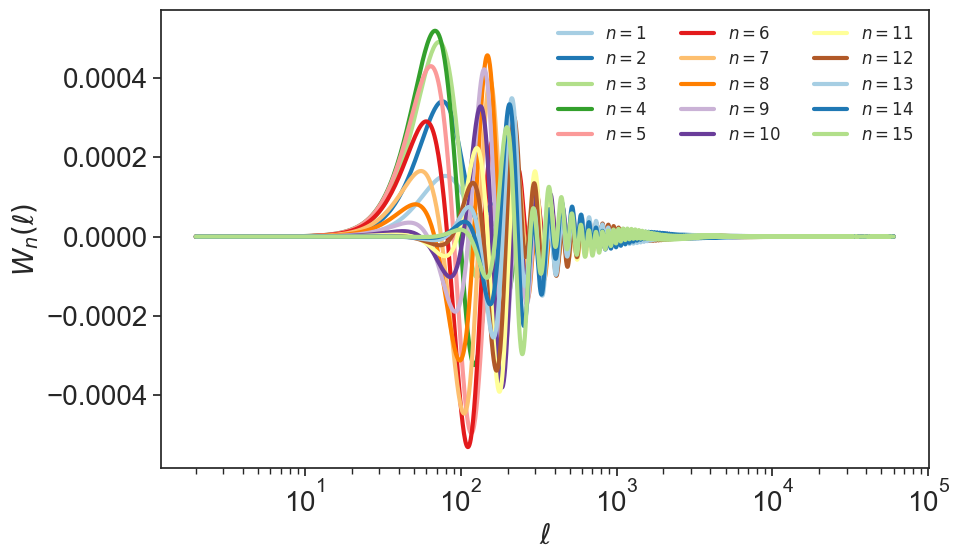

In [33]:
plt.figure(figsize=(10, 6))
for n in range(1, nmax+1):
    plt.semilogx(ells_integration, well[n], label=f"$n={n}$")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$W_n(\ell)$")
plt.legend(ncol=3, frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
cosebi_E = twopoint_sheshe.get_cosebis(
    ells_integration, 0, perturbations.k, well, np.arange(1, nmax+1)
)

/var/folders/b1/qymrqldd3fdbp79s76djm9240000gn/T/ipykernel_27928/763269727.py:6: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(


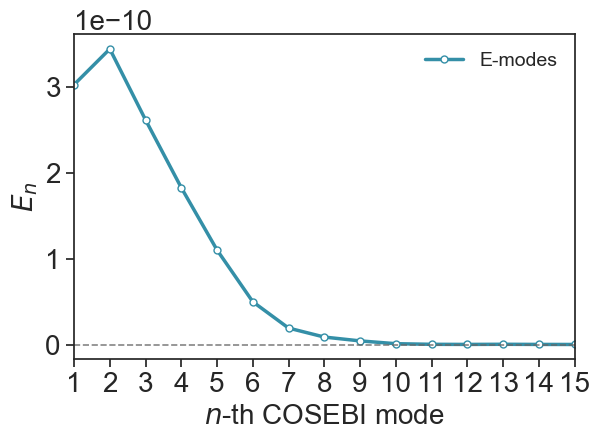

In [35]:
fig, ax = plt.subplots()

modes = np.arange(1, nmax + 1)
E11 = np.asarray(cosebi_E["SHE", "SHE", 1, 1].array[0, 0])

ax.plot(
    modes,
    E11,
    'o-',
    color=sns.color_palette("mako", 6)[3],
    lw=2.5,
    marker="o",
    ms=5,
    mfc="white",
    mec=sns.color_palette("mako", 6)[3],
    label="E-modes",
)

ax.axhline(0, color="0.4", lw=1.2, ls="--", alpha=0.8)

ax.set_xlabel(r"$n$-th COSEBI mode")
ax.set_ylabel(r"$E_n$")
ax.set_xlim(1, nmax)
ax.set_xticks(modes)

ax.tick_params(axis="both", which="both", direction="out")
ax.legend(frameon=False, loc="best")

plt.tight_layout()
plt.show()